In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau



from torchvision import transforms, models

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import copy

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report
import numpy as np
from sklearn.model_selection import StratifiedKFold


from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import pandas as pd

In [2]:
class MaskedImageDataset(Dataset):
    def __init__(self, data_dir, categories, transform=None, sample_size=None):
        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.class_names = []
        self.transform = transform
        self.label_map = {cat: i for i, cat in enumerate(categories)}
        self.inv_label_map = {i: cat for cat, i in self.label_map.items()}  # Szám → név átalakítás

        for category in categories:
            images_path = os.path.join(data_dir, category, "images")
            masks_path = os.path.join(data_dir, category, "masks")
            
            if not os.path.isdir(images_path) or not os.path.isdir(masks_path):
                continue
            
            files = os.listdir(images_path)
            if sample_size:  # If sample_size is given, limit the number of files
                files = files[:sample_size]  
                
            for file in tqdm(files, desc=f"Loading {category} images"):
                img_path = os.path.join(images_path, file)
                mask_path = os.path.join(masks_path, file)
                
                if os.path.exists(mask_path):
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)
                    self.labels.append(self.label_map[category])
                    self.class_names.append(category)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        label = self.labels[idx]
    
        # Load images and masks
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale
    
        # Resize both image and mask
        fixed_size = (256, 256)
        image = image.resize(fixed_size, Image.BILINEAR)
        mask = mask.resize(fixed_size, Image.NEAREST)
    
        # Apply transforms
        if self.transform:
            image = self.transform(image)  # apply full transform to image
        mask = transforms.ToTensor()(mask)  # only convert mask to tensor
    
        # Convert mask to binary (0 or 1)
        mask = (mask > 0.5).float()
    
        # Ensure mask has 3 channels like the image
        mask = mask.expand(3, -1, -1)  # shape [3, 256, 256]
    
        # Ensure shape match
        assert image.shape == mask.shape, f"Shape mismatch: {image.shape} vs {mask.shape}"
    
        # Apply mask to image
        masked_image = image * mask
    
        return masked_image, label

In [3]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # ResNet bemeneti mérete
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = MaskedImageDataset(data_dir='/kaggle/input/training-of-models/results/test_data',
                             categories=["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"],
                             transform=transform,
                             sample_size=None)

num_classes = len(dataset.label_map)
print(num_classes)

Loading Lung_Opacity images: 100%|██████████| 604/604 [00:01<00:00, 591.44it/s]

4


In [4]:
from torchvision.models import googlenet
import timm

# Load pre-trained Inception-ResNet-v2 model
inception_resnet_model = timm.create_model('inception_resnet_v2', pretrained=True)

# for param in model.parameters():
#     param.requires_grad = False  # Fagyasztjuk az alapmodelt

# Utolsó teljesen kapcsolt réteg (fc) cseréje saját osztályszámra
inception_resnet_model.classif = nn.Sequential(
    nn.Linear(inception_resnet_model.classif.in_features, 512),  # Első rejtett réteg
    nn.LeakyReLU(0.01),
    nn.Dropout(0.3),
    nn.Linear(512, 256),  # Második rejtett réteg
    nn.LeakyReLU(0.01),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)  # Kimeneti réteg
)

googlenet_model = googlenet(weights='IMAGENET1K_V1')  # Load pretrained weights
googlenet_model.fc = nn.Sequential(
    nn.Linear(googlenet_model.fc.in_features, 512),  # Első rejtett réteg
    nn.LeakyReLU(0.01),
    nn.Dropout(0.3),
    nn.Linear(512, 256),  # Második rejtett réteg
    nn.LeakyReLU(0.01),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)  # Kimeneti réteg
)
resnet50_model = models.resnet50(pretrained=True)
resnet50_model.fc = nn.Sequential(
    nn.Linear(resnet50_model.fc.in_features, 512),  # Első rejtett réteg
    nn.LeakyReLU(0.01),
    nn.Dropout(0.3),
    nn.Linear(512, 256),  # Második rejtett réteg
    nn.LeakyReLU(0.01),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)  # Kimeneti réteg
)

model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 234MB/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 228MB/s]


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

googlenet_path = '/kaggle/input/training-of-models/results/google_net.pth'
resnet50_path = '/kaggle/input/training-of-models/results/resnet50.pth'
inc_resnet_v2_path = '/kaggle/input/training-of-models/results/inc_resnet_v2.pth'
googlenet_model.load_state_dict(torch.load(googlenet_path, map_location=device))
googlenet_model.to(device)
googlenet_model.eval()  # Set to evaluation mode
print("GoogLeNet model loaded successfully!")

resnet50_model.load_state_dict(torch.load(resnet50_path, map_location=device))
resnet50_model.to(device)
resnet50_model.eval()  # Set to evaluation mode
print("ResNet50 model loaded successfully!")

inception_resnet_model.load_state_dict(torch.load(inc_resnet_v2_path, map_location=device))
inception_resnet_model.to(device)
inception_resnet_model.eval()  # Set to evaluation mode
print("InceptionResnetV2 model loaded successfully!")


<ipython-input-5-abc11a2b68c5>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  googlenet_model.load_state_dict(torch.load(googlenet_path, map_location=device))


Using device: cuda
GoogLeNet model loaded successfully!


<ipython-input-5-abc11a2b68c5>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50_model.load_state_dict(torch.load(resnet50_path, map_location=device))


ResNet50 model loaded successfully!


<ipython-input-5-abc11a2b68c5>:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inception_resnet_model.load_state_dict(torch.load(inc_resnet_v2_path, map_location=device))


InceptionResnetV2 model loaded successfully!


In [6]:
models = {
    'GoogLeNet': googlenet_model,
    'ResNet50': resnet50_model,
    'Inception-ResNet-v2': inception_resnet_model
}

Evaluating GoogLeNet...


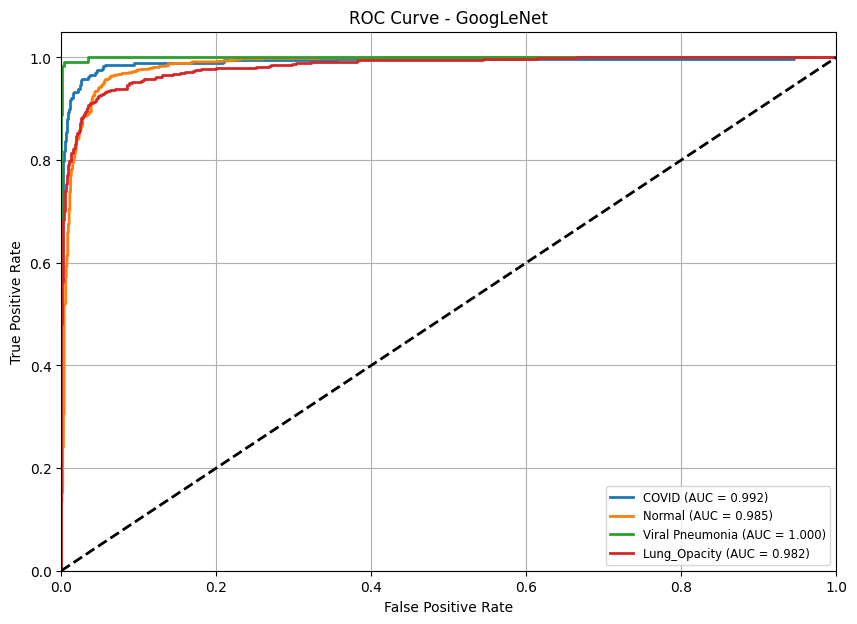

Evaluating ResNet50...


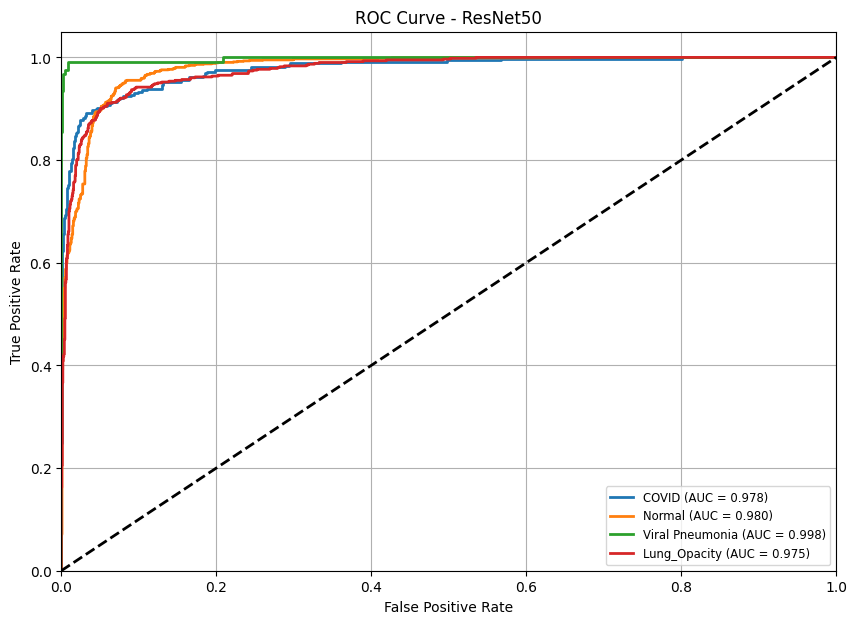

Evaluating Inception-ResNet-v2...


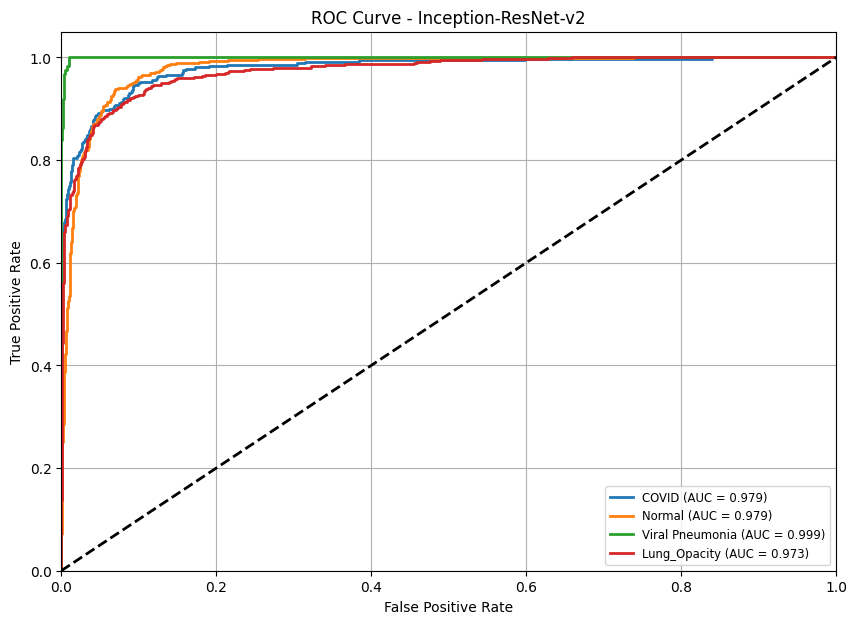

All model ROC plots generated successfully!


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4)

# Function to get predictions and labels
def get_predictions(model, dataloader):
    model.eval()
    y_true = []
    y_scores = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # Get probabilities for each class
            y_scores.extend(probs.cpu().numpy())   # Shape: [batch_size, num_classes]
            y_true.extend(labels.cpu().numpy())    # Shape: [batch_size]
    return np.array(y_true), np.array(y_scores)

# Number of classes
n_classes = len(set(dataset.labels))  # works with your custom dataset

# Plot setup

# Iterate over models
for name, model in models.items():
    print(f"Evaluating {name}...")
    model.to(device)

    # New figure for each model
    plt.figure(figsize=(10, 7))

    # Get predictions
    true_labels, scores = get_predictions(model, test_loader)

    # Binarize the true labels
    y_true_bin = label_binarize(true_labels, classes=range(n_classes))

    # Compute and plot ROC curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        class_name = dataset.inv_label_map[i]
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

    # Random classifier line
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    # Plot formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)

    # Save and show per model
    plt.savefig(f'{name}_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

print("All model ROC plots generated successfully!")